# Portfolio Project: Business Analytics
## Analysis of Delivery Delay Factors and Their Impact on Customer Satisfaction (Review Score)
Sumber Dataset: Brazilian E-Commerce Public Dataset by Olist

# Step 1: Data Preparation (Loading, Merging, and Cleaning)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

orders_path = 'archive/olist_orders_dataset.csv'
reviews_path = 'archive/olist_order_reviews_dataset.csv'

df_orders = pd.read_csv(orders_path)
df_reviews = pd.read_csv(reviews_path)

print(f"Number of rows in df_orders: {df_orders.shape[0]}")
print(f"Number of rows in df_reviews: {df_reviews.shape[0]}")

df_merged = pd.merge(df_orders, df_reviews, on='order_id', how='inner')
print(f"\nNumber of rows after merging: {df_merged.shape[0]}")

datetime_cols = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in datetime_cols:
    df_merged[col] = pd.to_datetime(df_merged[col])

print("\nNull values per column:\n", df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

df_clean = df_merged.dropna(subset=['order_delivered_customer_date']).copy()

print(f"\nNumber of rows after dropping undelivered orders: {df_clean.shape[0]}")

print("\nFirst 5 rows of the cleaned data:")
df_clean.head()

Number of rows in df_orders: 99441
Number of rows in df_reviews: 99224

Number of rows after merging: 99224

Null values per column:
 order_approved_at                  156
order_delivered_carrier_date      1756
order_delivered_customer_date     2865
review_comment_title             87656
review_comment_message           58247
dtype: int64

Number of rows after dropping undelivered orders: 96359

First 5 rows of the cleaned data:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17,2018-02-18 13:02:51


# Step 2: Exploratory Data Analysis (EDA) and Delay Calculation

Our analysis focus at this stage:

1. **Calculating Delivery Difference** — We calculate the actual vs estimated delivery duration to determine the delivery status (On Time vs Late).

2. **Review Score Distribution** — We look at the distribution of customer review scores.

3. **Correlation of Delivery Status vs Review Score** — We compare review scores between on-time and late orders.

Delivery Status Proportion:
 delivery_status
On Time    93.347793
Late        6.652207
Name: proportion, dtype: float64


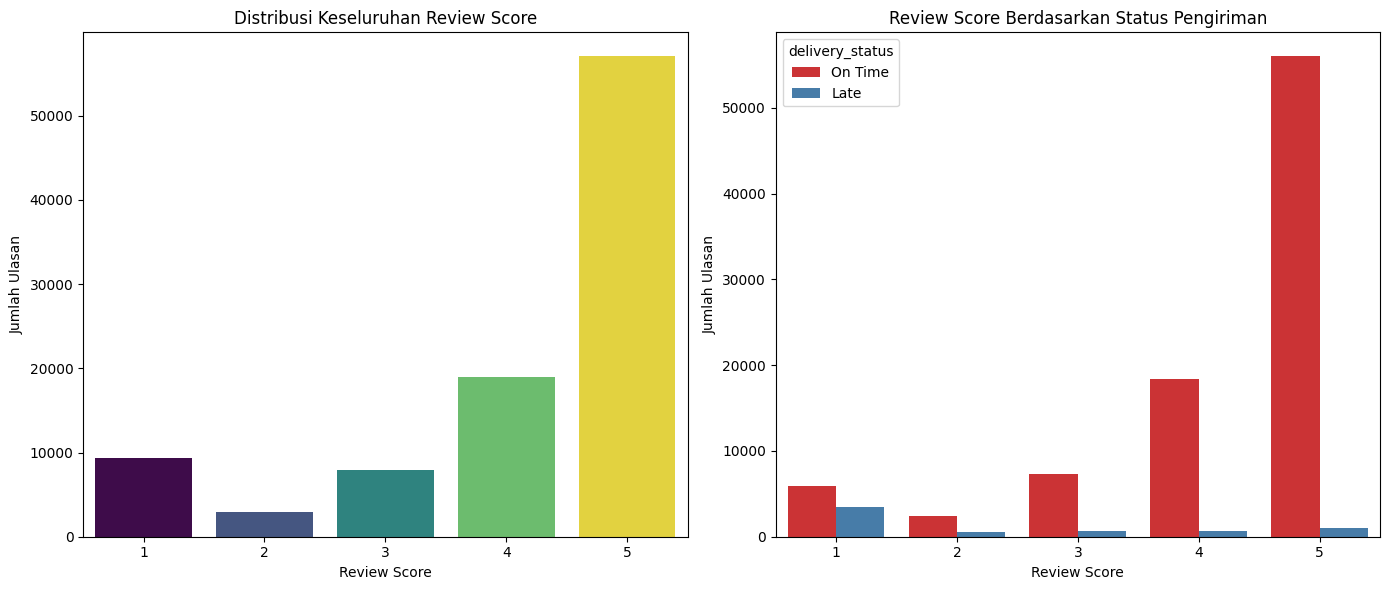


Average Review Score berdasarkan Status Pengiriman:
                 review_score
delivery_status              
Late                     2.27
On Time                  4.29


In [17]:

df_clean['delivery_delay_days'] = (df_clean['order_delivered_customer_date'] - df_clean['order_estimated_delivery_date']).dt.days

df_clean['delivery_status'] = np.where(df_clean['delivery_delay_days'] > 0, 'Late', 'On Time')

print("Delivery Status Proportion:\n", df_clean['delivery_status'].value_counts(normalize=True) * 100)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=df_clean, x='review_score', hue='review_score', palette='viridis', legend=False)
plt.title('Distribusi Keseluruhan Review Score')
plt.xlabel('Review Score')
plt.ylabel('Jumlah Ulasan')

plt.subplot(1, 2, 2)
sns.countplot(data=df_clean, x='review_score', hue='delivery_status', palette='Set1')
plt.title('Review Score Berdasarkan Status Pengiriman')
plt.xlabel('Review Score')
plt.ylabel('Jumlah Ulasan')

plt.tight_layout()
plt.show()

print("\nAverage Review Score berdasarkan Status Pengiriman:")
print(df_clean.groupby('delivery_status')[['review_score']].mean().round(2))

# Langkah 3: Rekayasa Feature & Akar Masalah Keterlambatan (Root Cause Analysis)

Mari kita bedah penyebab keterlambatan dengan menghitung dua metrik baru:
1. **Waktu Proses Penjual**: Berapa lama waktu yang dibutuhkan penjual untuk menyerahkan barang ke kurir sejak pesanan disetujui.
2. **Waktu Pengiriman Kurir**: Berapa lama waktu kurir mengirim barang ke pelanggan sejak menerima barang dari penjual.

Kita juga akan memuat dataset produk dan item pesanan untuk melihat apakah ada kategori produk tertentu yang lebih sering bermasalah.

Rata-rata Waktu (Hari) Berdasarkan Status Pengiriman:
                 seller_processing_days  courier_delivery_days
delivery_status                                               
Late                               5.05                  27.29
On Time                            2.15                   7.55


C:\Users\altha\AppData\Local\Temp\ipykernel_12592\2124817676.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_late_categories.values, y=top_late_categories.index, palette='Reds_r')


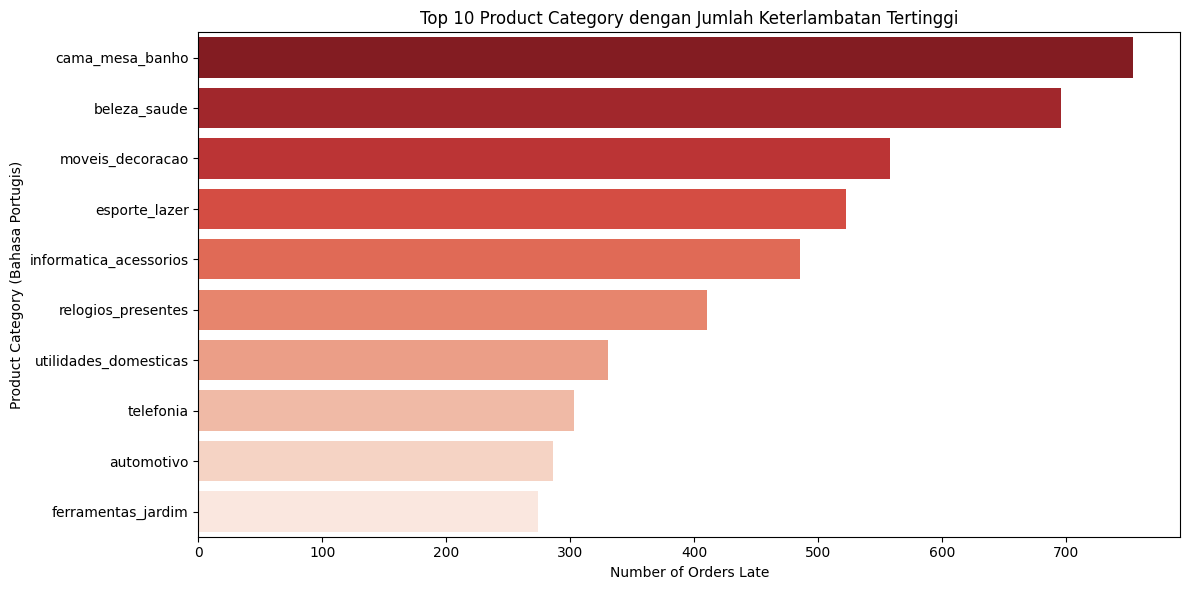

In [18]:
# 1. Menghitung Waktu Proses Penjual dan Waktu Kurir (dalam hari)
df_clean['seller_processing_days'] = (df_clean['order_delivered_carrier_date'] - df_clean['order_approved_at']).dt.days
df_clean['courier_delivery_days'] = (df_clean['order_delivered_customer_date'] - df_clean['order_delivered_carrier_date']).dt.days

# Menghapus nilai negatif anomali jika ada (kemungkinan kesalahan input data dari sistem logistik)
df_clean = df_clean[(df_clean['seller_processing_days'] >= 0) & (df_clean['courier_delivery_days'] >= 0)].copy()

# 2. Melihat rata-rata waktu berdasarkan status pengiriman
print("Rata-rata Waktu (Hari) Berdasarkan Status Pengiriman:")
print(df_clean.groupby('delivery_status')[['seller_processing_days', 'courier_delivery_days']].mean().round(2))

# 3. Memuat tabel tambahan untuk melihat kategori produk
items_path = 'archive/olist_order_items_dataset.csv'
products_path = 'archive/olist_products_dataset.csv'

df_items = pd.read_csv(items_path)
df_products = pd.read_csv(products_path)

# Menggabungkan df_clean dengan df_items (mendapatkan product_id) lalu dengan df_products (mendapatkan kategori)
df_root_cause = pd.merge(df_clean, df_items[['order_id', 'product_id', 'seller_id', 'freight_value', 'price']], on='order_id', how='left')
df_root_cause = pd.merge(df_root_cause, df_products[['product_id', 'product_category_name']], on='product_id', how='left')

# 4. Kategori produk mana yang paling sering terlambat?
# Filter hanya pesanan yang terlambat
df_late = df_root_cause[df_root_cause['delivery_status'] == 'Late']

# Hitung jumlah keterlambatan per kategori (Top 10)
top_late_categories = df_late['product_category_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_late_categories.values, y=top_late_categories.index, palette='Reds_r')
plt.title('Top 10 Product Category dengan Jumlah Keterlambatan Tertinggi')
plt.xlabel('Number of Orders Late')
plt.ylabel('Product Category (Bahasa Portugis)')
plt.tight_layout()
plt.show()

# Step 4: Geospatial Analysis (Worst Logistics Routes)

We will load the customer and seller datasets to get the origin and destination state data.
The goal is to find which logistics routes (e.g., from state SP to RJ) have the most severe delay percentages.

C:\Users\altha\AppData\Local\Temp\ipykernel_12592\451010188.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_worst_routes, x='late_percentage', y='delivery_route', palette='magma')


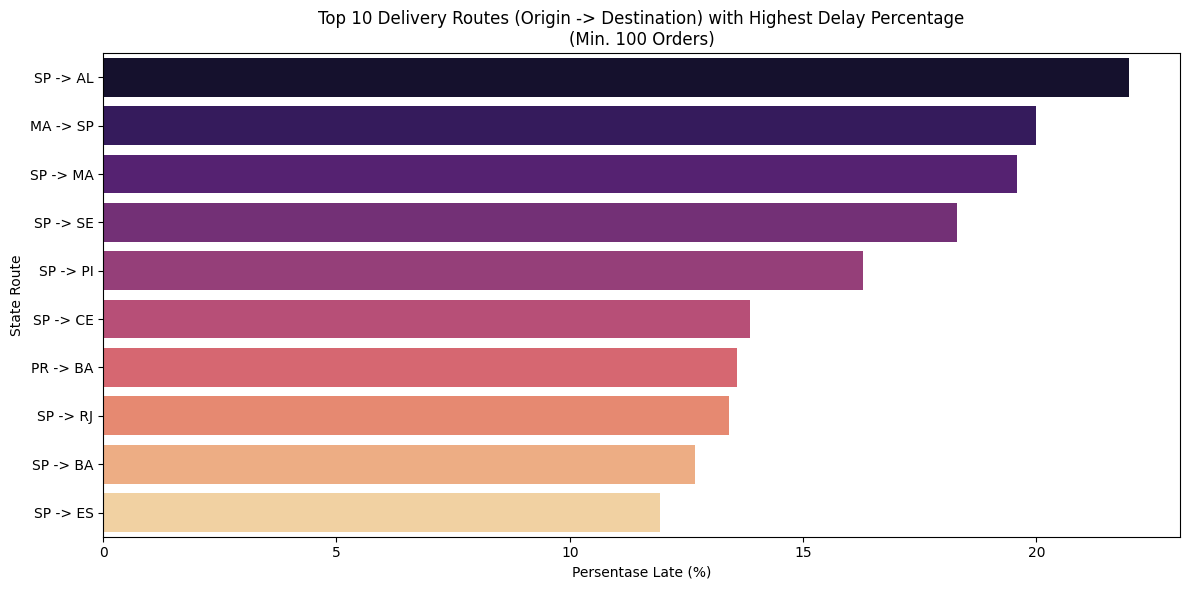

In [19]:
# 1. Load customer and seller location datasets
customers_path = 'archive/olist_customers_dataset.csv'
sellers_path = 'archive/olist_sellers_dataset.csv'

df_customers = pd.read_csv(customers_path)
df_sellers = pd.read_csv(sellers_path)

# Merge df_root_cause with location data
df_geo = pd.merge(df_root_cause, df_customers[['customer_id', 'customer_state']], on='customer_id', how='left')
df_geo = pd.merge(df_geo, df_sellers[['seller_id', 'seller_state']], on='seller_id', how='left')

# Create route column (Origin -> Destination)
df_geo['delivery_route'] = df_geo['seller_state'] + " -> " + df_geo['customer_state']

# 2. Worst Route Analysis
# Calculate total orders and total late orders per route
route_stats = df_geo.groupby('delivery_route').agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status', lambda x: (x == 'Late').sum())
).reset_index()

# Calculate delay percentage
route_stats['late_percentage'] = (route_stats['late_orders'] / route_stats['total_orders']) * 100

# Filter only routes with a minimum of 100 orders so the statistics are valid
route_stats_filtered = route_stats[route_stats['total_orders'] >= 100]

# Sort top 10 routes with the highest delay percentage
top_worst_routes = route_stats_filtered.sort_values(by='late_percentage', ascending=False).head(10)

# 3. Worst Route Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=top_worst_routes, x='late_percentage', y='delivery_route', palette='magma')
plt.title('Top 10 Delivery Routes (Origin -> Destination) with Highest Delay Percentage\n(Min. 100 Orders)')
plt.xlabel('Persentase Late (%)')
plt.ylabel('State Route')
plt.tight_layout()
plt.show()

# Step 5: Predictive Modeling (Machine Learning)

At this stage, we will build a Machine Learning model to predict whether a customer will give a bad review (1 or 2 Stars).
We will use a combination of features such as delivery duration, price, freight value, and product volume.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df_ml = df_geo.copy()
df_ml['bad_review'] = np.where(df_ml['review_score'] <= 2, 1, 0)


df_ml = pd.merge(df_ml, df_products[['product_id', 'product_length_cm', 'product_height_cm', 'product_width_cm']], on='product_id', how='left')


df_ml['product_volume_cm3'] = df_ml['product_length_cm'] * df_ml['product_height_cm'] * df_ml['product_width_cm']

# Select the numerical features to be used
features = ['seller_processing_days', 'courier_delivery_days', 'freight_value', 'price', 'product_volume_cm3']

# Drop rows with null values in these features so the model doesn't error
df_ml = df_ml.dropna(subset=features + ['bad_review']).copy()

X = df_ml[features]
y = df_ml['bad_review']

# 3. Data Splitting (Train-Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Number of training data: {X_train.shape[0]}")
print(f"Number of testing data: {X_test.shape[0]}")

Number of training data: 86713
Number of testing data: 21679


Overall Accuracy: 0.893

Classification Report:
               precision    recall  f1-score   support

    Good (0)       0.90      0.98      0.94     18466
     Bad (1)       0.76      0.40      0.53      3213

    accuracy                           0.89     21679
   macro avg       0.83      0.69      0.73     21679
weighted avg       0.88      0.89      0.88     21679



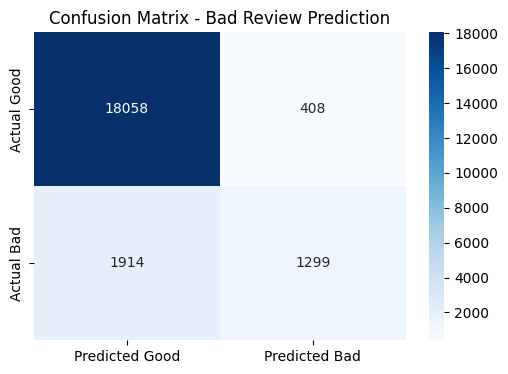

C:\Users\altha\AppData\Local\Temp\ipykernel_12592\1983523255.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')


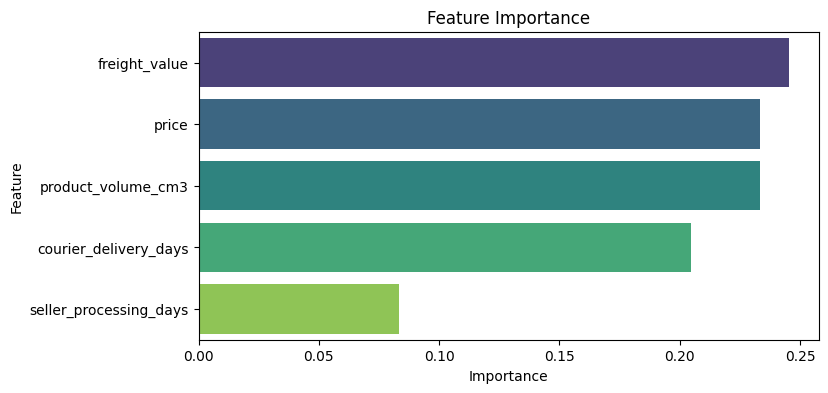

In [21]:
# 4. Random Forest Model Training
# Using class_weight='balanced' because the number of bad reviews is definitely much lower than good reviews
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 5. Model Evaluation
y_pred = rf_model.predict(X_test)

print("Overall Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Good (0)', 'Bad (1)']))

# 6. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Good', 'Predicted Bad'], yticklabels=['Actual Good', 'Actual Bad'])
plt.title('Confusion Matrix - Bad Review Prediction')
plt.show()

# 7. Feature mana yang paling penting?
feature_importances = pd.DataFrame({'Feature': features, 'Importance': rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance')
plt.show()

# Step 6: Text Analysis (Basic NLP) on Customer Complaints

As a conclusion, let's look at what customers actually write when their orders are late.
We will use basic Natural Language Processing (NLP) techniques to calculate the frequency of the most common words from the `review_comment_message` column.

C:\Users\altha\AppData\Local\Temp\ipykernel_12592\2190261708.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df, x='Frequency', y='Word', palette='Reds_r')


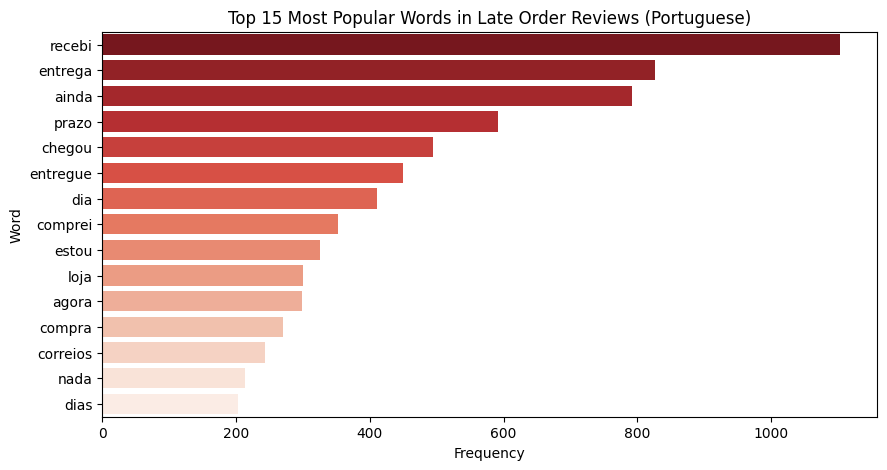

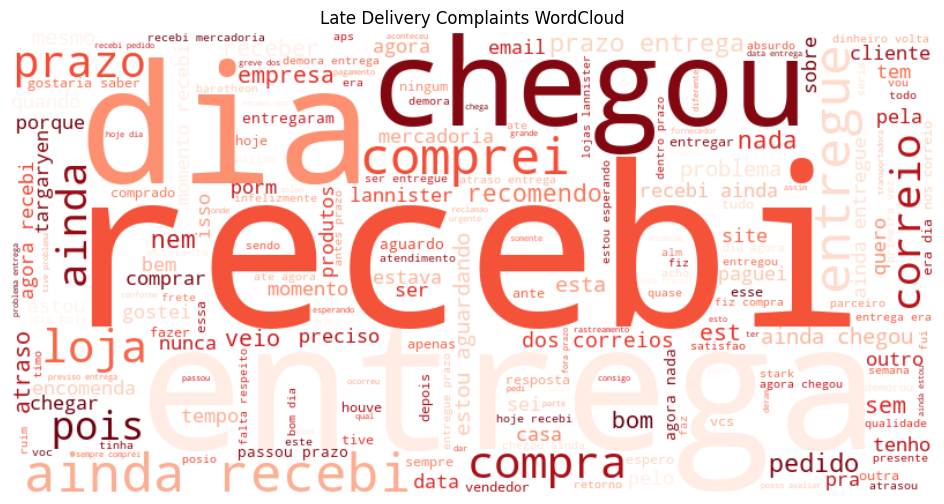

In [22]:
import re
from collections import Counter
from wordcloud import WordCloud

# 1. Filter text reviews only for late orders
df_text = df_clean[(df_clean['delivery_status'] == 'Late') & (df_clean['review_comment_message'].notnull())].copy()

# 2. Simple text cleaning function (lowercase, remove numbers and punctuation)
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text) # Leave only letters and spaces
    return text

df_text['cleaned_review'] = df_text['review_comment_message'].apply(clean_text)

# 3. Basic Portuguese stopwords collection (since Olist is from Brazil)
portuguese_stopwords = set(['o', 'a', 'os', 'as', 'um', 'uma', 'e', 'que', 'do', 'da', 'de', 'no', 'na', 
                            'com', 'para', 'por', 'como', 'mais', 'mas', 'foi', 'ao', 'ele', 'ela', 
                            'eu', 'meu', 'minha', 'muito', 'não', 'nao', 'já', 'ja', 'é', 'está', 'produto'])

# 4. Word extraction
all_words = []
for review in df_text['cleaned_review']:
    words = review.split()
    words = [word for word in words if word not in portuguese_stopwords and len(word) > 2]
    all_words.extend(words)

# Calculate frequency of the top 15 words
word_freq = Counter(all_words)
common_words = word_freq.most_common(15)

words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# 5. Visualization 1: Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=words_df, x='Frequency', y='Word', palette='Reds_r')
plt.title('Top 15 Most Popular Words in Late Order Reviews (Portuguese)')
plt.show()

# 6. Visualization 2: WordCloud
text_for_wordcloud = " ".join(all_words)
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_for_wordcloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Late Delivery Complaints WordCloud')
plt.show()
